In [1]:
pip install duckdb pandas pyarrow numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ------- -------------------------------- 2.4/13.1 MB 16.8 MB/s eta 0:00:01
   ------------------ --------------------- 6.0/13.1 MB 17.6 MB/s eta 0:00:01
   -------------------------------- ------- 10.5/13.1 MB 19.8 MB/s eta 0:00:01
   -------------------------------------- - 12.6/13.1 MB 19.7 MB/s eta 0:00:01
   -------------------------------------- - 12.6/13.1 MB 19.7 MB/s eta 0:00:01
   ---------------------------------------- 13.1/13.1 MB 12.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
pip install geopandas shapely pyogrio

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 18.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---- ----------------------------------- 2.4/22.9 MB 11.2 MB/s eta 0:00:02
   ------------ --------------------------- 7.1/22.9 MB 17.4 MB/s eta 0:00:01
   -------------------- ------------------- 11.8/22.9 MB 19.4 MB/s eta 0:00:01
   ---------------------------- ----------- 16.3/22.9 MB 19.7 MB/s eta 0:00:01
   ------------------------------------- -- 21.8/22.9 MB 21.2 MB/s eta 0:00:01
   ---------------------------------------- 22.9/22.9 MB 20.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------------------------- ------------- 4.2/6.3 MB 22.9 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 21.5 MB/s eta 0:00:00
Note: you m

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import duckdb
# Sampling 10% data records from 2024_NOAA_AIS_logs_01.parquet for a demo EDA
input_file = input_file = "2024_NOAA_AIS_logs_01.parquet"
output_file = "ais_sampled_vessels_10pct.parquet"

con = duckdb.connect()

con.execute(f"""
COPY (
    WITH sampled_mmsi AS (
        SELECT MMSI
        FROM (
            SELECT DISTINCT MMSI
            FROM read_parquet('{input_file}')
            WHERE MMSI IS NOT NULL
        )
        USING SAMPLE 10 PERCENT (reservoir)
    )
    SELECT t.*
    FROM read_parquet('{input_file}') AS t
    INNER JOIN sampled_mmsi AS s
    ON t.MMSI = s.MMSI
)
TO '{output_file}' (FORMAT PARQUET);
""")

print("Done")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Done


In [3]:
import os
print(os.path.exists(output_file)) #check if sampling works

True


## Step 0. Define methods

In [1]:
import os
import json
import warnings
import time
from typing import Dict, Tuple
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

warnings.filterwarnings("ignore")

INPUT_PARQUET = "ais_sampled_vessels_10pct.parquet"
INPUT_STATIC_PARQUET = "2024_NOAA_AIS_ships_01.parquet"
OUTPUT_DIR = "ais_output"

PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
CLEAN_DIR = os.path.join(OUTPUT_DIR, "cleaned_data")
LOG_DIR = os.path.join(OUTPUT_DIR, "logs")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

STATUS_MAP = {
    0: "Under way using engine",
    1: "At anchor",
    2: "Not under command",
    3: "Restricted maneuverability",
    4: "Constrained by draft",
    5: "Moored",
    6: "Aground",
    7: "Engaged in fishing",
    8: "Under way sailing",
    9: "Reserved",
    10: "Reserved",
    11: "Reserved",
    12: "Reserved",
    13: "Reserved",
    14: "AIS-SART / MOB / EPIRB",
    15: "Undefined",
}

VESSEL_TYPE_MAP = {
    20: "Wing in ground",
    21: "Wing in ground - Hazard A",
    22: "Wing in ground - Hazard B",
    23: "Wing in ground - Hazard C",
    24: "Wing in ground - Hazard D",
    30: "Fishing",
    31: "Towing",
    32: "Towing astern",
    33: "Dredging or underwater ops",
    34: "Diving ops",
    35: "Military ops",
    36: "Sailing",
    37: "Pleasure craft",
    40: "High-speed craft",
    41: "High-speed craft - Hazard A",
    42: "High-speed craft - Hazard B",
    43: "High-speed craft - Hazard C",
    44: "High-speed craft - Hazard D",
    50: "Pilot vessel",
    51: "Search and rescue",
    52: "Tug",
    53: "Port tender",
    54: "Anti-pollution",
    55: "Law enforcement",
    56: "Spare local vessel",
    57: "Spare local vessel",
    58: "Medical transport",
    59: "Noncombatant ship",
    60: "Passenger",
    61: "Passenger - Hazard A",
    62: "Passenger - Hazard B",
    63: "Passenger - Hazard C",
    64: "Passenger - Hazard D",
    70: "Cargo",
    71: "Cargo - Hazard A",
    72: "Cargo - Hazard B",
    73: "Cargo - Hazard C",
    74: "Cargo - Hazard D",
    80: "Tanker",
    81: "Tanker - Hazard A",
    82: "Tanker - Hazard B",
    83: "Tanker - Hazard C",
    84: "Tanker - Hazard D",
    90: "Other",
    91: "Other - Hazard A",
    92: "Other - Hazard B",
    93: "Other - Hazard C",
    94: "Other - Hazard D",
}

def save_text(text: str, filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(text)


def save_json(obj: Dict, filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)


def save_dataframe(df: pd.DataFrame, filepath_csv: str = None, filepath_parquet: str = None) -> None:
    if filepath_csv is not None:
        df.to_csv(filepath_csv, index=False)
    if filepath_parquet is not None:
        df.to_parquet(filepath_parquet, index=False)


def close_plot(filepath: str, dpi: int = 180, show_in_notebook: bool = True) -> None:
    plt.tight_layout()
    plt.savefig(filepath, dpi=dpi, bbox_inches="tight")

    if show_in_notebook:
        display(plt.gcf())

    plt.close()


def haversine_np(lon1, lat1, lon2, lat2):
    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371.0088 * c
    return km


def log_step(step_name: str, start_time: float, global_start: float) -> None:
    step_elapsed = time.time() - start_time
    total_elapsed = time.time() - global_start
    print(f"[DONE] {step_name} | step time: {step_elapsed:.2f}s | total time: {total_elapsed:.2f}s")


def log_start(step_name: str) -> float:
    print(f"[START] {step_name} ...")
    return time.time()


def get_us_extent():
    xlim = (-130, -60)
    ylim = (20, 55)
    return xlim, ylim


def plot_basemap(ax, xlim=None, ylim=None):
    try:
        world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    except Exception:
        world = gpd.read_file(
            "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        )

    if xlim is None or ylim is None:
        xlim, ylim = get_us_extent()

    world = world.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]

    world.plot(
        ax=ax,
        color="#E6E6E6",
        edgecolor="#888888",
        linewidth=0.4,
        zorder=0
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_facecolor("white")
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.35)

def load_data(parquet_path: str) -> pd.DataFrame:
    return pd.read_parquet(parquet_path)

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    rename_map = {}
    for c in df.columns:
        cl = c.lower()
        if cl == "basedatetime":
            rename_map[c] = "BaseDateTime"
        elif cl == "mmsi":
            rename_map[c] = "MMSI"
        elif cl == "lat":
            rename_map[c] = "LAT"
        elif cl == "lon":
            rename_map[c] = "LON"
        elif cl == "sog":
            rename_map[c] = "SOG"
        elif cl == "cog":
            rename_map[c] = "COG"
        elif cl == "heading":
            rename_map[c] = "Heading"
        elif cl == "status":
            rename_map[c] = "Status"
        elif cl == "vesselname":
            rename_map[c] = "VesselName"
        elif cl == "imo":
            rename_map[c] = "IMO"
        elif cl == "callsign":
            rename_map[c] = "CallSign"
        elif cl == "vesseltype":
            rename_map[c] = "VesselType"
        elif cl == "length":
            rename_map[c] = "Length"
        elif cl == "width":
            rename_map[c] = "Width"
        elif cl == "draft":
            rename_map[c] = "Draft"
        elif cl == "cargo":
            rename_map[c] = "Cargo"
        elif cl == "transceiverclass":
            rename_map[c] = "TransceiverClass"

    return df.rename(columns=rename_map)


def convert_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "MMSI" in df.columns:
        df["MMSI"] = df["MMSI"].astype("string").str.strip()

    if "BaseDateTime" in df.columns:
        df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"], errors="coerce", utc=True)

    numeric_cols = [
        "LAT", "LON", "SOG", "COG", "Heading", "Status",
        "VesselType", "Length", "Width", "Draft", "Cargo"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

def build_data_quality_report(df: pd.DataFrame) -> Dict:
    report = {
        "n_rows": int(len(df)),
        "n_columns": int(df.shape[1]),
        "columns": df.columns.tolist(),
        "missing_ratio": {col: float(df[col].isna().mean()) for col in df.columns},
        "dtypes": {col: str(dtype) for col, dtype in df.dtypes.items()},
    }

    if "MMSI" in df.columns:
        report["n_unique_mmsi"] = int(df["MMSI"].nunique(dropna=True))

    if "BaseDateTime" in df.columns:
        report["time_min"] = str(df["BaseDateTime"].min())
        report["time_max"] = str(df["BaseDateTime"].max())

    return report

def remove_duplicates(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    df = df.copy()
    stats = {}

    before = len(df)
    df = df.drop_duplicates()
    after_full = len(df)

    subset_cols = [c for c in ["MMSI", "BaseDateTime", "LAT", "LON"] if c in df.columns]
    if subset_cols:
        df = df.drop_duplicates(subset=subset_cols, keep="first")
    after_subset = len(df)

    stats["rows_before"] = int(before)
    stats["rows_after_full_row_dedup"] = int(after_full)
    stats["rows_after_key_dedup"] = int(after_subset)
    stats["n_removed_full_row_duplicates"] = int(before - after_full)
    stats["n_removed_key_duplicates"] = int(after_full - after_subset)
    return df, stats


def clean_core_missing(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    df = df.copy()
    stats = {}

    required_cols = [c for c in ["MMSI", "BaseDateTime", "LAT", "LON"] if c in df.columns]
    before = len(df)
    df = df.dropna(subset=required_cols)
    after = len(df)

    stats["rows_before"] = int(before)
    stats["rows_after"] = int(after)
    stats["n_removed"] = int(before - after)
    stats["required_cols"] = required_cols
    return df, stats


def clean_lat_lon(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    df = df.copy()
    stats = {}

    before = len(df)

    if "LAT" in df.columns:
        df = df[(df["LAT"] >= -90) & (df["LAT"] <= 90)]
    if "LON" in df.columns:
        df = df[(df["LON"] >= -180) & (df["LON"] <= 180)]

    if "LAT" in df.columns and "LON" in df.columns:
        df = df[~((df["LAT"] == 0) & (df["LON"] == 0))]

    after = len(df)
    stats["rows_before"] = int(before)
    stats["rows_after"] = int(after)
    stats["n_removed"] = int(before - after)
    return df, stats


def clean_navigation_values(df: pd.DataFrame) -> Tuple[pd.DataFrame, Dict]:
    df = df.copy()
    stats = {}

    if "SOG" in df.columns:
        df.loc[df["SOG"] < 0, "SOG"] = np.nan
        df.loc[df["SOG"] > 80, "SOG"] = np.nan

    if "COG" in df.columns:
        df.loc[(df["COG"] < 0) | (df["COG"] >= 360), "COG"] = np.nan

    if "Heading" in df.columns:
        df.loc[(df["Heading"] < 0) | (df["Heading"] > 360), "Heading"] = np.nan

    if "Status" in df.columns:
        df.loc[(df["Status"] < 0) | (df["Status"] > 15), "Status"] = np.nan

    if "VesselType" in df.columns:
        df.loc[(df["VesselType"] < 0) | (df["VesselType"] > 99), "VesselType"] = np.nan

    stats["note"] = "Invalid navigation values are set to NaN."
    return df, stats

def build_static_vesseltype_lookup(df_static: pd.DataFrame) -> pd.DataFrame:
    use_cols = [c for c in ["MMSI", "VesselType"] if c in df_static.columns]
    lookup = df_static[use_cols].copy()

    lookup = lookup.dropna(subset=["MMSI"])
    if "VesselType" in lookup.columns:
        lookup = lookup.dropna(subset=["VesselType"])

    lookup = lookup.drop_duplicates(subset=["MMSI"], keep="first")
    return lookup


def merge_static_vesseltype(df_dynamic: pd.DataFrame, df_static: pd.DataFrame) -> pd.DataFrame:
    df_dynamic = df_dynamic.copy()
    lookup = build_static_vesseltype_lookup(df_static)

    if "VesselType" in df_dynamic.columns:
        lookup = lookup.rename(columns={"VesselType": "VesselType_static"})
        df_dynamic = df_dynamic.merge(lookup, on="MMSI", how="left")
        df_dynamic["VesselType"] = df_dynamic["VesselType"].fillna(df_dynamic["VesselType_static"])
        df_dynamic = df_dynamic.drop(columns=["VesselType_static"])
    else:
        df_dynamic = df_dynamic.merge(lookup, on="MMSI", how="left")

    return df_dynamic


def add_mapped_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "Status" in df.columns:
        df["StatusLabel"] = df["Status"].map(STATUS_MAP).fillna("Unknown")

    if "VesselType" in df.columns:
        df["VesselTypeLabel"] = df["VesselType"].map(VESSEL_TYPE_MAP).fillna("Unknown")

    return df

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "BaseDateTime" in df.columns:
        dt = df["BaseDateTime"]
        df["Year"] = dt.dt.year
        df["Month"] = dt.dt.month
        df["Day"] = dt.dt.day
        df["Hour"] = dt.dt.hour
        df["Date"] = dt.dt.date.astype("string")
        df["DayOfWeek"] = dt.dt.dayofweek
        df["IsWeekend"] = dt.dt.dayofweek.isin([5, 6]).astype(int)

    return df


def add_trajectory_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    required = {"MMSI", "BaseDateTime", "LAT", "LON"}
    if not required.issubset(df.columns):
        return df

    df = df.sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True)

    df["PrevLAT"] = df.groupby("MMSI")["LAT"].shift(1)
    df["PrevLON"] = df.groupby("MMSI")["LON"].shift(1)
    df["PrevTime"] = df.groupby("MMSI")["BaseDateTime"].shift(1)

    df["DeltaHours"] = (df["BaseDateTime"] - df["PrevTime"]).dt.total_seconds() / 3600.0

    df["StepKm"] = haversine_np(
        df["PrevLON"],
        df["PrevLAT"],
        df["LON"],
        df["LAT"]
    )

    df.loc[df["PrevLAT"].isna() | df["PrevLON"].isna(), "StepKm"] = np.nan

    df["ImpliedSpeedKmh"] = df["StepKm"] / df["DeltaHours"]
    df.loc[(df["DeltaHours"] <= 0) | (df["DeltaHours"].isna()), "ImpliedSpeedKmh"] = np.nan

    df["TrackBreak"] = (
        df["PrevTime"].isna()
        | (df["DeltaHours"] > 6)
        | (df["ImpliedSpeedKmh"] > 100)
    ).astype(int)

    df["TrackSegmentID"] = df.groupby("MMSI")["TrackBreak"].cumsum()

    return df

def build_unique_vessel_type_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Count number of unique vessels per vessel type.
    Only vessels appearing in the dynamic AIS file are counted.
    """
    required_cols = {"MMSI", "VesselTypeLabel"}
    if not required_cols.issubset(df.columns):
        return pd.DataFrame()

    vessel_level = (
        df[["MMSI", "VesselTypeLabel"]]
        .dropna(subset=["MMSI"])
        .drop_duplicates(subset=["MMSI"], keep="first")
    )

    result = (
        vessel_level.groupby("VesselTypeLabel")["MMSI"]
        .nunique()
        .reset_index(name="n_unique_vessels")
        .sort_values("n_unique_vessels", ascending=False)
    )
    return result

def build_summary_tables(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    tables = {}

    numeric_cols = [
        c for c in
        ["LAT", "LON", "SOG", "COG", "Heading", "Status", "VesselType", "DeltaHours", "StepKm", "ImpliedSpeedKmh"]
        if c in df.columns
    ]
    if numeric_cols:
        tables["numeric_summary"] = (
            df[numeric_cols]
            .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
            .T.reset_index()
            .rename(columns={"index": "variable"})
        )

    tables["missingness"] = pd.DataFrame({
        "column": df.columns,
        "missing_count": [df[c].isna().sum() for c in df.columns],
        "missing_ratio": [df[c].isna().mean() for c in df.columns],
    }).sort_values("missing_ratio", ascending=False)

    if "StatusLabel" in df.columns:
        tables["status_counts"] = (
            df.groupby("StatusLabel")
            .size()
            .reset_index(name="n_records")
            .sort_values("n_records", ascending=False)
        )

    if "VesselTypeLabel" in df.columns:
        tables["vessel_type_counts_record_level"] = (
            df.groupby("VesselTypeLabel")
            .size()
            .reset_index(name="n_records")
            .sort_values("n_records", ascending=False)
        )

    unique_vessel_type_table = build_unique_vessel_type_table(df)
    if len(unique_vessel_type_table) > 0:
        tables["unique_vessel_type_counts"] = unique_vessel_type_table

    if "Hour" in df.columns:
        tables["hourly_counts"] = (
            df.groupby("Hour")
            .size()
            .reset_index(name="n_records")
            .sort_values("Hour")
        )

    if "Date" in df.columns:
        tables["daily_counts"] = (
            df.groupby("Date")
            .size()
            .reset_index(name="n_records")
            .sort_values("Date")
        )

    if "MMSI" in df.columns:
        agg_dict = {
            "n_records": ("MMSI", "size"),
            "time_min": ("BaseDateTime", "min"),
            "time_max": ("BaseDateTime", "max"),
        }

        if "TrackSegmentID" in df.columns:
            agg_dict["n_segments"] = ("TrackSegmentID", "nunique")
        if "SOG" in df.columns:
            agg_dict["mean_sog"] = ("SOG", "mean")
            agg_dict["max_sog"] = ("SOG", "max")
        if "StepKm" in df.columns:
            agg_dict["total_step_km"] = ("StepKm", "sum")
        if "ImpliedSpeedKmh" in df.columns:
            agg_dict["mean_implied_speed_kmh"] = ("ImpliedSpeedKmh", "mean")
        if "VesselTypeLabel" in df.columns:
            agg_dict["vessel_type_label"] = ("VesselTypeLabel", "first")

        vessel_stats = df.groupby("MMSI").agg(**agg_dict).reset_index()

        vessel_stats["duration_hours"] = (
            vessel_stats["time_max"] - vessel_stats["time_min"]
        ).dt.total_seconds() / 3600.0

        tables["per_vessel_stats"] = vessel_stats.sort_values("n_records", ascending=False)

    return tables

def plot_missingness(df: pd.DataFrame, filepath: str) -> None:
    missing_ratio = df.isna().mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    plt.bar(missing_ratio.index, missing_ratio.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing ratio")
    plt.title("Missingness by column")
    close_plot(filepath)


def plot_spatial_hexbin(df: pd.DataFrame, filepath: str) -> None:
    if not {"LON", "LAT"}.issubset(df.columns):
        print("[WARN] plot_spatial_hexbin skipped: missing LON/LAT.")
        return

    plot_df = df[["LON", "LAT"]].dropna()

    if len(plot_df) == 0:
        print("[WARN] plot_spatial_hexbin skipped: no valid coordinates.")
        return

    xlim, ylim = get_us_extent()
    plot_df = plot_df[
        (plot_df["LON"] >= xlim[0]) & (plot_df["LON"] <= xlim[1]) &
        (plot_df["LAT"] >= ylim[0]) & (plot_df["LAT"] <= ylim[1])
    ].copy()

    if len(plot_df) == 0:
        print("[WARN] plot_spatial_hexbin skipped: no points inside U.S. extent.")
        return

    if len(plot_df) > 300000:
        plot_df = plot_df.sample(300000, random_state=42)

    fig, ax = plt.subplots(figsize=(11, 8))
    plot_basemap(ax, xlim=xlim, ylim=ylim)

    hb = ax.hexbin(
        plot_df["LON"],
        plot_df["LAT"],
        gridsize=120,
        bins="log",
        mincnt=1,
        cmap="viridis",
        linewidths=0.0,
        zorder=2
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("AIS Position Density in U.S. Waters")

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("log10(count)")

    close_plot(filepath)


def plot_sog_hist(df: pd.DataFrame, filepath: str) -> None:
    if "SOG" not in df.columns:
        return

    plot_df = df["SOG"].dropna()

    plt.figure(figsize=(9, 6))
    plt.hist(plot_df, bins=80)
    plt.xlabel("SOG (knots)")
    plt.ylabel("Count")
    plt.title("Speed over ground distribution")
    close_plot(filepath)


def plot_heading_hist(df: pd.DataFrame, filepath: str) -> None:
    if "Heading" not in df.columns:
        return

    plot_df = df["Heading"].dropna()

    plt.figure(figsize=(9, 6))
    plt.hist(plot_df, bins=72)
    plt.xlabel("Heading (degrees)")
    plt.ylabel("Count")
    plt.title("Heading distribution")
    close_plot(filepath)


def plot_cog_hist(df: pd.DataFrame, filepath: str) -> None:
    if "COG" not in df.columns:
        return

    plot_df = df["COG"].dropna()

    plt.figure(figsize=(9, 6))
    plt.hist(plot_df, bins=72)
    plt.xlabel("COG (degrees)")
    plt.ylabel("Count")
    plt.title("COG distribution")
    close_plot(filepath)


def plot_status_bar(df: pd.DataFrame, filepath: str) -> None:
    if "StatusLabel" not in df.columns:
        return

    counts = df["StatusLabel"].value_counts(dropna=False)

    plt.figure(figsize=(12, 6))
    plt.bar(counts.index, counts.values)
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of records")
    plt.title("Record count by navigation status")
    close_plot(filepath)


def plot_unique_vessel_type_bar(df: pd.DataFrame, filepath: str, top_n: int = 20) -> None:
    """
    Plot number of unique vessels per vessel type.
    """
    table = build_unique_vessel_type_table(df)
    if len(table) == 0:
        print("[WARN] plot_unique_vessel_type_bar skipped: missing MMSI or VesselTypeLabel.")
        return

    plot_df = table.head(top_n)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["VesselTypeLabel"], plot_df["n_unique_vessels"])
    plt.xticks(rotation=60, ha="right")
    plt.ylabel("Number of unique vessels")
    plt.title("Unique vessel count by vessel type")
    close_plot(filepath)


def plot_hourly_activity(df: pd.DataFrame, filepath: str) -> None:
    if "Hour" not in df.columns:
        return

    counts = df.groupby("Hour").size().reindex(range(24), fill_value=0)

    plt.figure(figsize=(10, 5))
    plt.plot(counts.index, counts.values, marker="o")
    plt.xlabel("Hour of day")
    plt.ylabel("Number of records")
    plt.title("Hourly AIS activity")
    close_plot(filepath)


def plot_daily_activity(df: pd.DataFrame, filepath: str, max_days: int = 60) -> None:
    if "Date" not in df.columns:
        return

    counts = df.groupby("Date").size().reset_index(name="n_records").sort_values("Date")
    if len(counts) > max_days:
        counts = counts.head(max_days)

    plt.figure(figsize=(12, 5))
    plt.plot(range(len(counts)), counts["n_records"].values, marker="o")
    plt.xlabel("Day index")
    plt.ylabel("Number of records")
    plt.title("Daily AIS activity")
    close_plot(filepath)


def plot_per_vessel_record_distribution(df: pd.DataFrame, filepath: str) -> None:
    if "MMSI" not in df.columns:
        return

    counts = df.groupby("MMSI").size()

    plt.figure(figsize=(9, 6))
    plt.hist(counts, bins=80)
    plt.xlabel("Number of records per vessel")
    plt.ylabel("Number of vessels")
    plt.title("Per-vessel record count distribution")
    close_plot(filepath)


def plot_sample_trajectories(
    df: pd.DataFrame,
    filepath: str,
    n_vessels: int = 200,
    min_records: int = 50,
    max_gap_hours: float = 3.0,
    max_step_km: float = 100.0,
    max_speed_kmh: float = 200.0
) -> None:
    required = {"MMSI", "LAT", "LON", "BaseDateTime"}
    if not required.issubset(df.columns):
        print("[WARN] plot_sample_trajectories skipped: missing required columns.")
        return

    vessel_counts = df.groupby("MMSI").size()
    selected = vessel_counts[vessel_counts >= min_records].sort_values(ascending=False).head(n_vessels).index.tolist()

    if len(selected) == 0:
        print("[WARN] plot_sample_trajectories skipped: no vessels meet min_records threshold.")
        return

    print(f"[INFO] Number of vessels selected for trajectory plot: {len(selected)}")

    plot_df = df[df["MMSI"].isin(selected)].copy()
    plot_df = plot_df.sort_values(["MMSI", "BaseDateTime"]).reset_index(drop=True)

    if len(plot_df) == 0:
        print("[WARN] plot_sample_trajectories skipped: no trajectory points after filtering.")
        return

    plot_df["PrevLAT_plot"] = plot_df.groupby("MMSI")["LAT"].shift(1)
    plot_df["PrevLON_plot"] = plot_df.groupby("MMSI")["LON"].shift(1)
    plot_df["PrevTime_plot"] = plot_df.groupby("MMSI")["BaseDateTime"].shift(1)

    plot_df["DeltaHours_plot"] = (
        plot_df["BaseDateTime"] - plot_df["PrevTime_plot"]
    ).dt.total_seconds() / 3600.0

    plot_df["StepKm_plot"] = haversine_np(
        plot_df["PrevLON_plot"],
        plot_df["PrevLAT_plot"],
        plot_df["LON"],
        plot_df["LAT"]
    )
    plot_df.loc[
        plot_df["PrevLAT_plot"].isna() | plot_df["PrevLON_plot"].isna(),
        "StepKm_plot"
    ] = np.nan

    plot_df["ImpliedSpeedKmh_plot"] = plot_df["StepKm_plot"] / plot_df["DeltaHours_plot"]
    plot_df.loc[
        (plot_df["DeltaHours_plot"] <= 0) | (plot_df["DeltaHours_plot"].isna()),
        "ImpliedSpeedKmh_plot"
    ] = np.nan

    plot_df["TrackBreak_plot"] = (
        plot_df["PrevTime_plot"].isna()
        | (plot_df["DeltaHours_plot"] > max_gap_hours)
        | (plot_df["StepKm_plot"] > max_step_km)
        | (plot_df["ImpliedSpeedKmh_plot"] > max_speed_kmh)
    ).astype(int)

    plot_df["TrackSegment_plot"] = plot_df.groupby("MMSI")["TrackBreak_plot"].cumsum()

    xlim, ylim = get_us_extent()
    plot_df = plot_df[
        (plot_df["LON"] >= xlim[0]) & (plot_df["LON"] <= xlim[1]) &
        (plot_df["LAT"] >= ylim[0]) & (plot_df["LAT"] <= ylim[1])
    ].copy()

    if len(plot_df) == 0:
        print("[WARN] plot_sample_trajectories skipped: no selected trajectory points inside U.S. extent.")
        return

    fig, ax = plt.subplots(figsize=(11, 8))
    plot_basemap(ax, xlim=xlim, ylim=ylim)

    for _, sub in plot_df.groupby(["MMSI", "TrackSegment_plot"]):
        if len(sub) >= 2:
            ax.plot(
                sub["LON"],
                sub["LAT"],
                color="#1f4e79",
                linewidth=0.35,
                alpha=0.22,
                zorder=2
            )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Sample Vessel Trajectories in U.S. Waters ({len(selected)} vessels)")

    close_plot(filepath)

## Step 1. Load Dynamic AIS Data

This step loads the dynamic and static AIS parquet file containing timestamped vessel positions, ship infos and navigation-related attributes.

In [3]:

global_start = time.time()
print("=" * 80)
print("AIS preprocessing + EDA pipeline started")
print("=" * 80)

step_start = log_start("Step 1 - Load dynamic AIS data")
df_raw = load_data(INPUT_PARQUET)
save_text(
    f"Dynamic raw shape: {df_raw.shape}\nColumns:\n" + "\n".join(df_raw.columns.tolist()),
    os.path.join(LOG_DIR, "01_dynamic_raw_overview.txt")
)
print("[INFO] Dynamic raw columns:")
for i, col in enumerate(df_raw.columns.tolist(), 1):
    print(f"  {i:02d}. {col}")
log_step("Step 1 - Load dynamic AIS data", step_start, global_start)

step_start = log_start("Step 2 - Load static vessel info")
df_static_raw = load_data(INPUT_STATIC_PARQUET)
save_text(
    f"Static raw shape: {df_static_raw.shape}\nColumns:\n" + "\n".join(df_static_raw.columns.tolist()),
    os.path.join(LOG_DIR, "02_static_raw_overview.txt")
)
print("[INFO] Static raw columns:")
for i, col in enumerate(df_static_raw.columns.tolist(), 1):
    print(f"  {i:02d}. {col}")
log_step("Step 2 - Load static vessel info", step_start, global_start)

step_start = log_start("Step 3 - Standardize columns and convert dtypes")
df = standardize_columns(df_raw)
df = convert_dtypes(df)

df_static = standardize_columns(df_static_raw)
df_static = convert_dtypes(df_static)

print("[INFO] Dynamic columns after standardization:")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"  {i:02d}. {col}")

print("[INFO] Static columns after standardization:")
for i, col in enumerate(df_static.columns.tolist(), 1):
    print(f"  {i:02d}. {col}")

quality_before = build_data_quality_report(df)
save_json(quality_before, os.path.join(LOG_DIR, "03_quality_before_cleaning.json"))
log_step("Step 3 - Standardize columns and convert dtypes", step_start, global_start)

AIS preprocessing + EDA pipeline started
[START] Step 1 - Load dynamic AIS data ...
[INFO] Dynamic raw columns:
  01. MMSI
  02. BaseDateTime
  03. LAT
  04. LON
  05. SOG
  06. COG
  07. Heading
  08. Status
[DONE] Step 1 - Load dynamic AIS data | step time: 1.57s | total time: 1.57s
[START] Step 2 - Load static vessel info ...
[INFO] Static raw columns:
  01. MMSI
  02. VesselName
  03. IMO
  04. CallSign
  05. VesselType
  06. Length
  07. Width
  08. Draft
  09. Cargo
  10. TransceiverClass
  11. BaseDateTime
[DONE] Step 2 - Load static vessel info | step time: 0.05s | total time: 1.62s
[START] Step 3 - Standardize columns and convert dtypes ...
[INFO] Dynamic columns after standardization:
  01. MMSI
  02. BaseDateTime
  03. LAT
  04. LON
  05. SOG
  06. COG
  07. Heading
  08. Status
[INFO] Static columns after standardization:
  01. MMSI
  02. VesselName
  03. IMO
  04. CallSign
  05. VesselType
  06. Length
  07. Width
  08. Draft
  09. Cargo
  10. TransceiverClass
  11. BaseDa

## Step 2. Data Cleaning

This step attempts to clean up duplicate records, invalid records due to missing key attributes, and records with invalid values. Then, it removes missing values ​​from the remaining records.

In [6]:
step_start = log_start("Step 4 - Data cleaning")
cleaning_log = {}

sub_start = log_start("  4.1 Remove duplicates")
df, stats_dedup = remove_duplicates(df)
cleaning_log["remove_duplicates"] = stats_dedup
log_step("  4.1 Remove duplicates", sub_start, global_start)

sub_start = log_start("  4.2 Clean core missing fields")
df, stats_core_missing = clean_core_missing(df)
cleaning_log["clean_core_missing"] = stats_core_missing
log_step("  4.2 Clean core missing fields", sub_start, global_start)

sub_start = log_start("  4.3 Clean latitude/longitude")
df, stats_latlon = clean_lat_lon(df)
cleaning_log["clean_lat_lon"] = stats_latlon
log_step("  4.3 Clean latitude/longitude", sub_start, global_start)

sub_start = log_start("  4.4 Clean navigation values")
df, stats_nav = clean_navigation_values(df)
cleaning_log["clean_navigation_values"] = stats_nav
log_step("  4.4 Clean navigation values", sub_start, global_start)

quality_after_cleaning = build_data_quality_report(df)
save_json(quality_after_cleaning, os.path.join(LOG_DIR, "04a_quality_after_basic_cleaning.json"))
log_step("Step 4 - Data cleaning", step_start, global_start)

[START] Step 4 - Data cleaning ...
[START]   4.1 Remove duplicates ...
[DONE]   4.1 Remove duplicates | step time: 29.79s | total time: 46.84s
[START]   4.2 Clean core missing fields ...
[DONE]   4.2 Clean core missing fields | step time: 3.69s | total time: 50.54s
[START]   4.3 Clean latitude/longitude ...
[DONE]   4.3 Clean latitude/longitude | step time: 4.29s | total time: 54.83s
[START]   4.4 Clean navigation values ...
[DONE]   4.4 Clean navigation values | step time: 1.64s | total time: 56.47s
[DONE] Step 4 - Data cleaning | step time: 41.07s | total time: 58.13s


## Step 3. Feature Engineering

This step merges the cleaned dynamic AIS data and vessel type information from the static vessel file. Then it generates label, time-based, and trajectory-related features.

In [8]:
step_start = log_start("Step 5 - Merge VesselType from static file")
df = merge_static_vesseltype(df, df_static)
save_json(
    {
        "dynamic_rows_after_merge": int(len(df)),
        "dynamic_unique_mmsi_after_merge": int(df["MMSI"].nunique(dropna=True)) if "MMSI" in df.columns else None,
        "vesseltype_missing_ratio_after_merge": float(df["VesselType"].isna().mean()) if "VesselType" in df.columns else None,
    },
    os.path.join(LOG_DIR, "04b_static_merge_summary.json")
)
log_step("Step 5 - Merge VesselType from static file", step_start, global_start)

step_start = log_start("Step 6 - Feature engineering")

sub_start = log_start("  6.1 Add mapped labels")
df = add_mapped_labels(df)
log_step("  6.1 Add mapped labels", sub_start, global_start)

sub_start = log_start("  6.2 Add time features")
df = add_time_features(df)
log_step("  6.2 Add time features", sub_start, global_start)

sub_start = log_start("  6.3 Add trajectory features")
df = add_trajectory_features(df)
log_step("  6.3 Add trajectory features", sub_start, global_start)

quality_after = build_data_quality_report(df)
save_json(quality_after, os.path.join(LOG_DIR, "05_quality_after_cleaning_and_merge.json"))
save_json(cleaning_log, os.path.join(LOG_DIR, "06_cleaning_log.json"))
log_step("Step 6 - Feature engineering", step_start, global_start)

[START] Step 5 - Merge VesselType from static file ...
[DONE] Step 5 - Merge VesselType from static file | step time: 6.99s | total time: 65.17s
[START] Step 6 - Feature engineering ...
[START]   6.1 Add mapped labels ...
[DONE]   6.1 Add mapped labels | step time: 5.12s | total time: 70.29s
[START]   6.2 Add time features ...
[DONE]   6.2 Add time features | step time: 18.16s | total time: 88.45s
[START]   6.3 Add trajectory features ...
[DONE]   6.3 Add trajectory features | step time: 56.58s | total time: 145.03s
[DONE] Step 6 - Feature engineering | step time: 88.91s | total time: 154.08s


## Step 4. Saving and Summarizing

In [10]:
step_start = log_start("Step 7 - Save cleaned dataset")
save_dataframe(
    df,
    filepath_parquet=os.path.join(CLEAN_DIR, "ais_cleaned_with_vesseltype.parquet")
)
log_step("Step 7 - Save cleaned dataset", step_start, global_start)

step_start = log_start("Step 8 - Build summary tables")
tables = build_summary_tables(df)
log_step("Step 8 - Build summary tables", step_start, global_start)

step_start = log_start("Step 9 - Save summary tables")
for name, table in tables.items():
    sub_start = log_start(f"  9.x Save table: {name}")
    save_dataframe(
        table,
        filepath_csv=os.path.join(TABLES_DIR, f"{name}.csv"),
        filepath_parquet=os.path.join(TABLES_DIR, f"{name}.parquet")
    )
    log_step(f"  9.x Save table: {name}", sub_start, global_start)
log_step("Step 9 - Save summary tables", step_start, global_start)

[START] Step 7 - Save cleaned dataset ...
[DONE] Step 7 - Save cleaned dataset | step time: 34.21s | total time: 188.36s
[START] Step 8 - Build summary tables ...
[DONE] Step 8 - Build summary tables | step time: 49.33s | total time: 237.69s
[START] Step 9 - Save summary tables ...
[START]   9.x Save table: numeric_summary ...
[DONE]   9.x Save table: numeric_summary | step time: 0.13s | total time: 237.82s
[START]   9.x Save table: missingness ...
[DONE]   9.x Save table: missingness | step time: 0.00s | total time: 237.82s
[START]   9.x Save table: status_counts ...
[DONE]   9.x Save table: status_counts | step time: 0.00s | total time: 237.82s
[START]   9.x Save table: vessel_type_counts_record_level ...
[DONE]   9.x Save table: vessel_type_counts_record_level | step time: 0.00s | total time: 237.82s
[START]   9.x Save table: unique_vessel_type_counts ...
[DONE]   9.x Save table: unique_vessel_type_counts | step time: 0.00s | total time: 237.82s
[START]   9.x Save table: hourly_coun

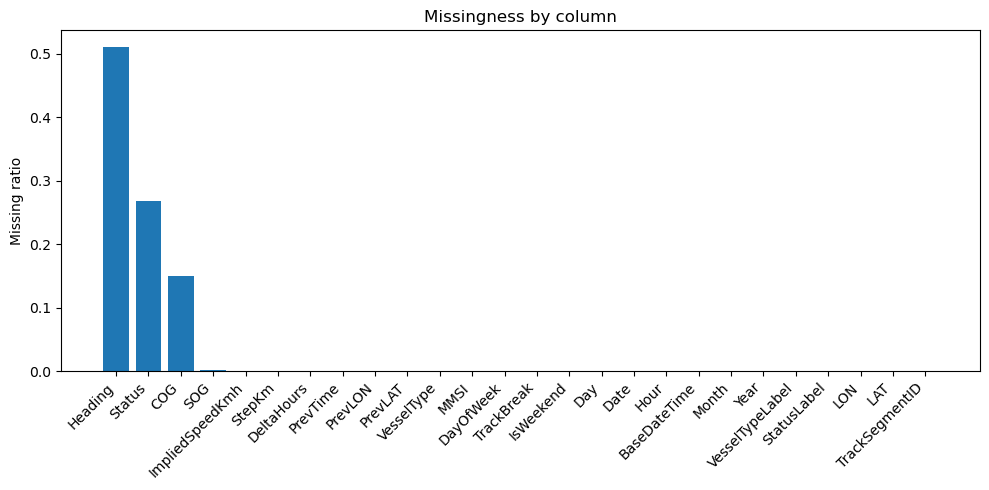

In [11]:
plot_missingness(df, os.path.join(PLOTS_DIR, "missingness.png")) # Missing rate of each attribute

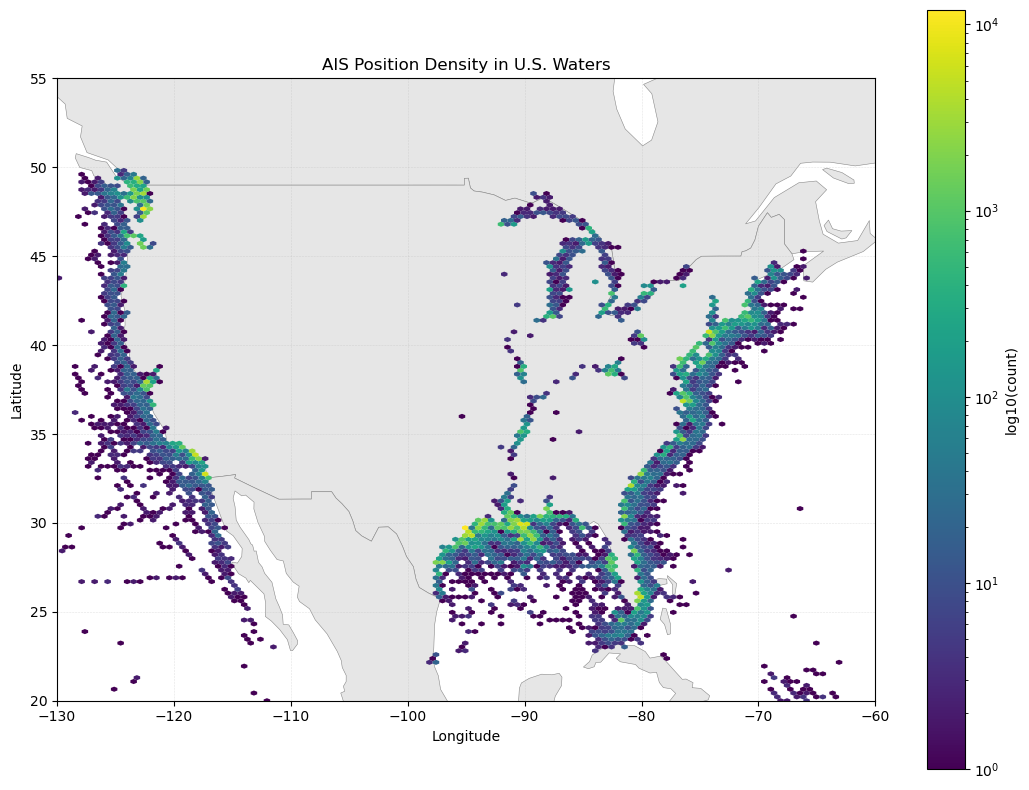

In [12]:
plot_spatial_hexbin(df, os.path.join(PLOTS_DIR, "spatial_hexbin.png")) # Position density of sampled records

[INFO] Number of vessels selected for trajectory plot: 2000


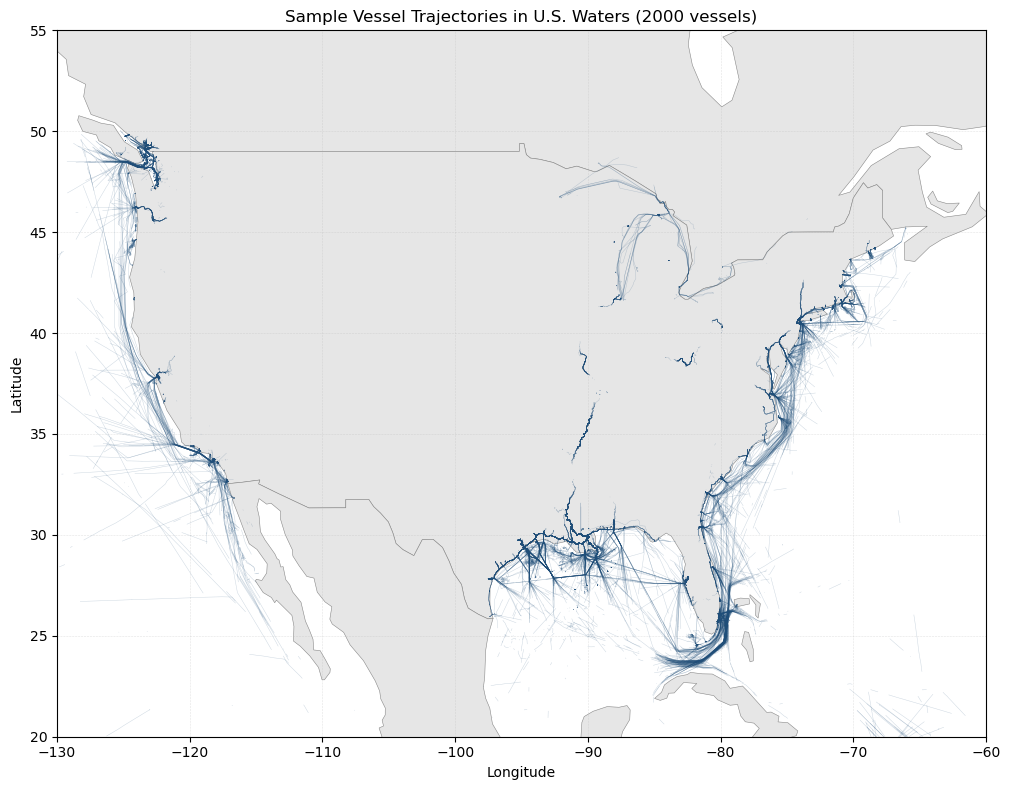

In [13]:
plot_sample_trajectories( # Trajectories of top 2000 ships with the most records
    df,
    os.path.join(PLOTS_DIR, "sample_trajectories.png"),
    n_vessels=2000,
    min_records=50,
    max_gap_hours=3.0,
    max_step_km=100.0,
    max_speed_kmh=200.0
)

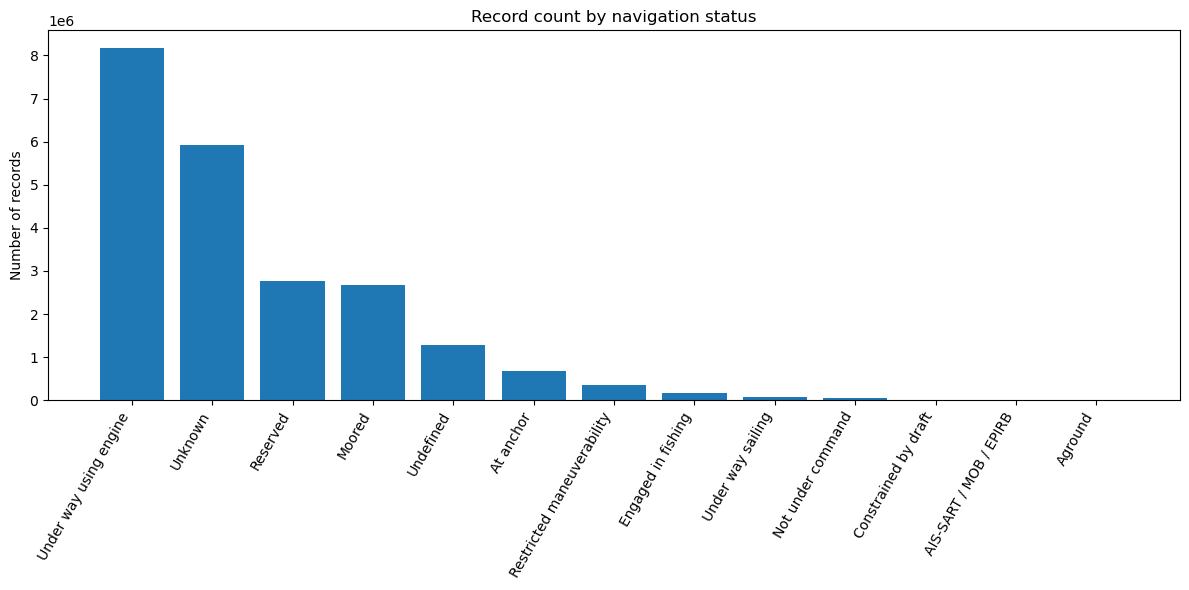

In [14]:
plot_status_bar(df, os.path.join(PLOTS_DIR, "status_counts.png")) # Status of each record

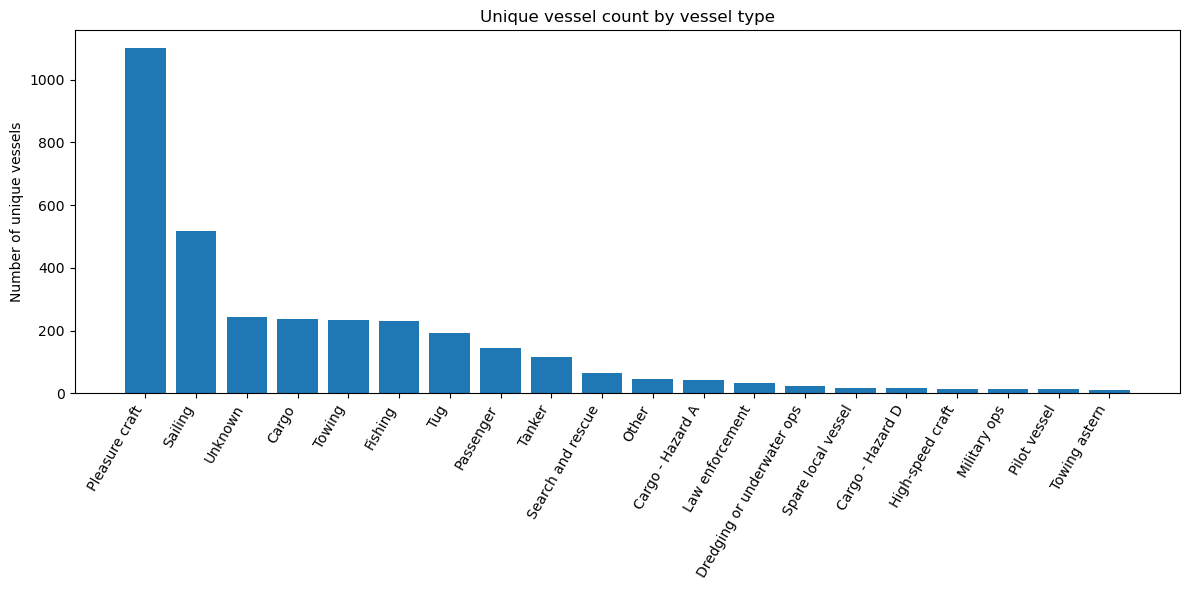

In [15]:
plot_unique_vessel_type_bar(df, os.path.join(PLOTS_DIR, "unique_vessel_type_distribution.png")) # categorize vessels by VesselType

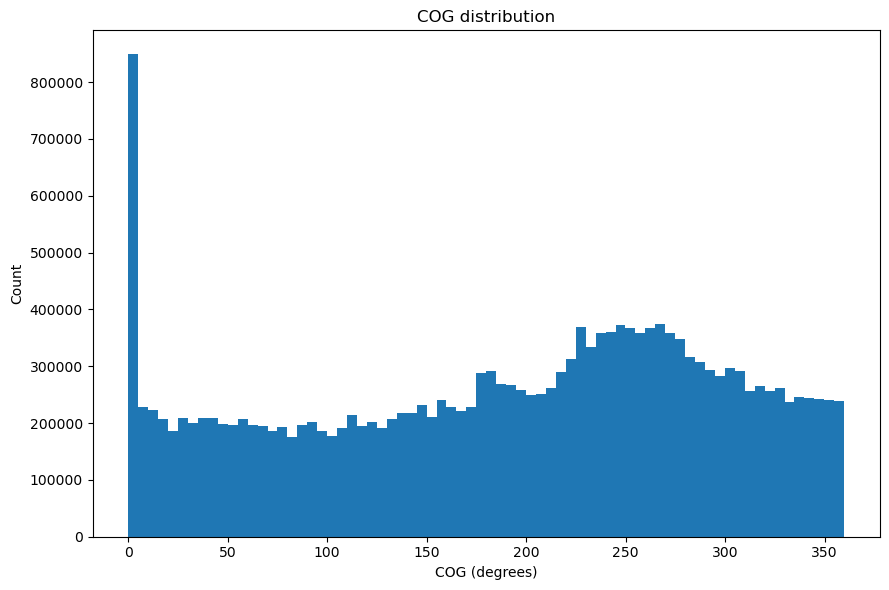

In [16]:
plot_cog_hist(df, os.path.join(PLOTS_DIR, "cog_distribution.png")) # distribution of Course Over Ground

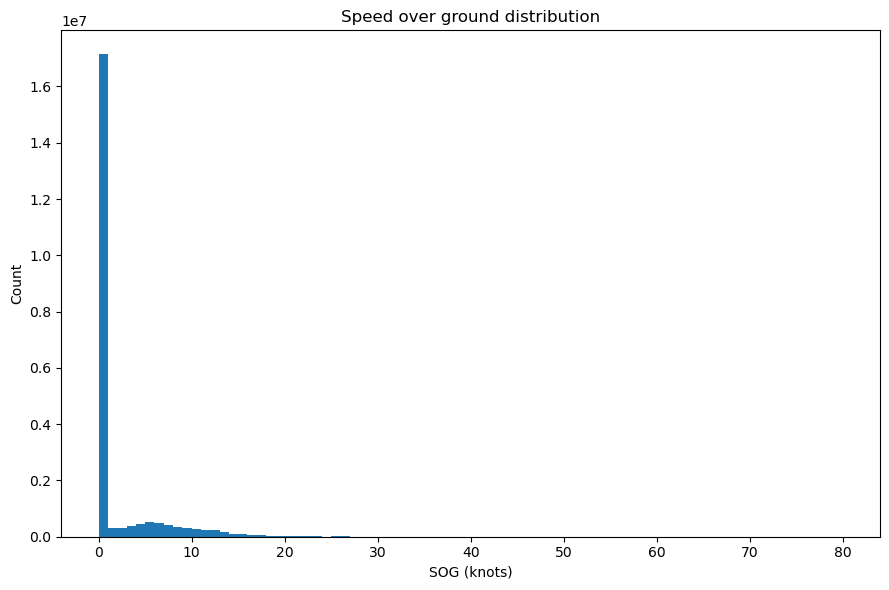

In [17]:
plot_sog_hist(df, os.path.join(PLOTS_DIR, "sog_distribution.png")) # distribution of Speed Over Ground

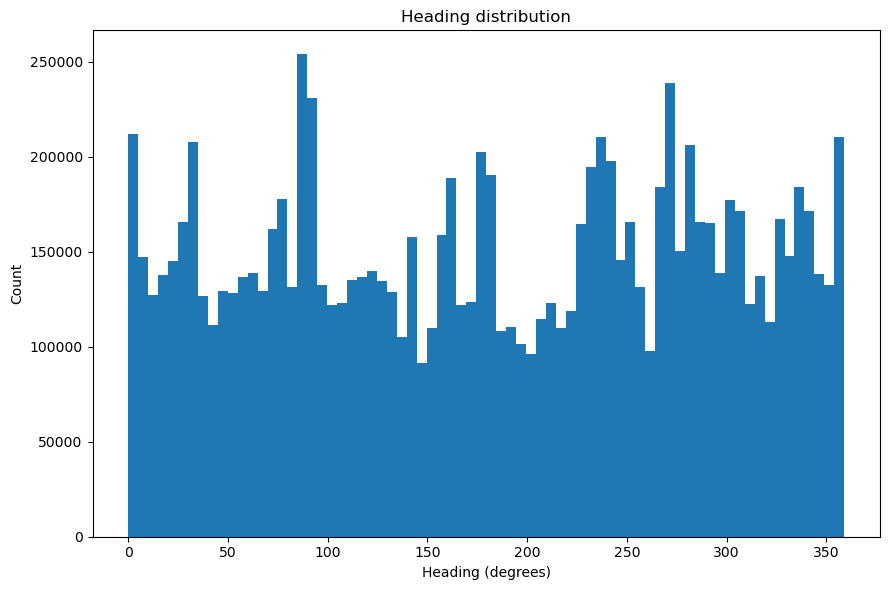

In [18]:
plot_heading_hist(df, os.path.join(PLOTS_DIR, "heading_distribution.png")) # distribution of The direction the vessel’s bow is pointing

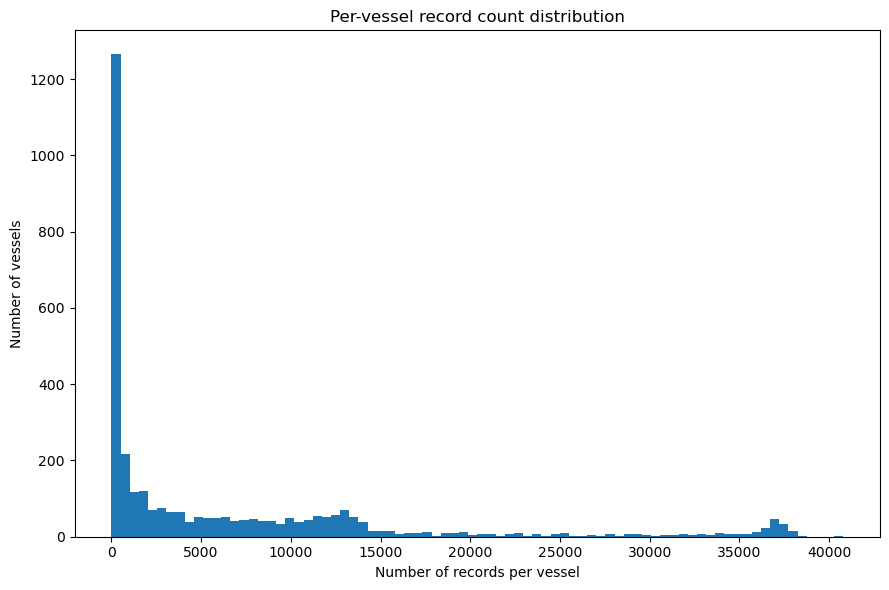

In [19]:
plot_per_vessel_record_distribution(df, os.path.join(PLOTS_DIR, "per_vessel_record_distribution.png")) # how many record does a vessel have?

In [20]:
step_start = log_start("Step 11 - Save final summary")
unique_vessel_type_table = build_unique_vessel_type_table(df)

final_summary = {
    "raw_dynamic_rows": int(len(df_raw)),
    "raw_static_rows": int(len(df_static_raw)),
    "cleaned_rows": int(len(df)),
    "raw_dynamic_unique_vessels": int(df_raw["MMSI"].astype("string").nunique(dropna=True)) if "MMSI" in df_raw.columns else None,
    "cleaned_unique_vessels": int(df["MMSI"].nunique(dropna=True)) if "MMSI" in df.columns else None,
    "unique_vessels_with_vesseltype_table_rows": int(len(unique_vessel_type_table)),
    "vesseltype_missing_ratio_final": float(df["VesselType"].isna().mean()) if "VesselType" in df.columns else None,
    "time_min": str(df["BaseDateTime"].min()) if "BaseDateTime" in df.columns else None,
    "time_max": str(df["BaseDateTime"].max()) if "BaseDateTime" in df.columns else None,
    "output_dir": OUTPUT_DIR,
}
save_json(final_summary, os.path.join(LOG_DIR, "07_final_summary.json"))
log_step("Step 11 - Save final summary", step_start, global_start)

print("=" * 80)
print(f"Pipeline finished successfully in {time.time() - global_start:.2f}s")
print("=" * 80)

[START] Step 11 - Save final summary ...
[DONE] Step 11 - Save final summary | step time: 18.54s | total time: 521.77s
Pipeline finished successfully in 521.77s
